In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import numpy as np 

import random 

import time 

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.graph_inference import Graph as Graph_interference
from src.models.graph_training import Graph as Graph_train

from src.models.utils import project_points
# from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Test 1 - points projection

In [33]:
def random_pose(x_low, x_high):
    shift = torch.tensor([(random.random() * (x_high - x_low) + x_low) for _ in range(3)])
    rotation = torch.randn((4,))
    rotation = F.normalize(rotation, p=2, dim=0)

    return torch.cat([shift, rotation], dim=0).unsqueeze(0)
    

In [37]:
## === prepare test case data ===

pts_boundaries = torch.tensor((100, 65*torch.pi/180, 20*torch.pi/180), dtype = torch.long).unsqueeze(0) # x, y
test_pts_n = 40

origin_pts = torch.rand((test_pts_n, 3)) * pts_boundaries

print(f'Generated {origin_pts.shape[0]} test points.')

origin_pose = random_pose(-10, 10)
target_pose = random_pose(-10, 10)

print(f'Generated poses:\n  origin: {origin_pose}\n  target: {target_pose}')

Generated 40 test points.
Generated poses:
  origin: tensor([[-5.8374, -5.7041,  7.7088,  0.4505,  0.0394,  0.4031, -0.7956]])
  target: tensor([[ 4.9699, -9.1312, -2.3303, -0.2859, -0.1546, -0.0755,  0.9427]])


In [38]:
projected_pts = project_points(origin_pts, origin_pose, target_pose)

print(f'{projected_pts.shape}')

torch.Size([40, 3])


In [47]:
# === fcn to gt calc

def polar_to_cartesian_vec(r, theta, phi):

    x = r * np.cos(phi) * np.cos(theta)
    y = r * np.cos(phi) * np.sin(theta)
    z = r * np.sin(phi)
    
    return np.stack([x, y, z], axis=-1)

def cartesian_to_polar_vec(xyz):

    r = np.linalg.norm(xyz, axis=1)

    eps = 1e-8

    theta = np.arctan2(xyz[:, 1], xyz[:, 0])
    
    phi = np.arcsin(np.clip(xyz[:, 2] / (r + eps), -1.0, 1.0))
    
    return np.stack([r, theta, phi], axis=-1)


def project_points_gt(origin_pts, origin_pose, target_pose):

    origin_pts = np.array(origin_pts) 
    
    origin_pose = np.array(origin_pose).squeeze() 
    target_pose = np.array(target_pose).squeeze()

    origin_pts_cartesian = polar_to_cartesian_vec(origin_pts[:,0], origin_pts[:,1], origin_pts[:,2])

    t_src = origin_pose[:3]
    q_src = origin_pose[3:]
    rot_src = R.from_quat(q_src)

    P_world = rot_src.apply(origin_pts_cartesian) + t_src

    t_tgt = target_pose[:3]
    q_tgt = target_pose[3:]
    rot_tgt = R.from_quat(q_tgt)
    
    target_pts_cartesian = rot_tgt.inv().apply(P_world - t_tgt)

    target_pts = cartesian_to_polar_vec(target_pts_cartesian)

    return target_pts

In [49]:
# === calc gt === 

gt_pts = project_points_gt(origin_pts, origin_pose, target_pose)

In [80]:
def visu(proj_pts, gt_pts, orig_pts):

    proj_pts = np.array(proj_pts)
    proj_pts = polar_to_cartesian_vec(proj_pts[:,0], proj_pts[:,1], proj_pts[:,2])
    gt_pts =  polar_to_cartesian_vec(gt_pts[:,0], gt_pts[:,1], gt_pts[:,2])
    orig_pts = np.array(orig_pts)
    orig_pts = polar_to_cartesian_vec(orig_pts[:,0], orig_pts[:,1], orig_pts[:,2])


    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    error = []

    for i in range(proj_pts.shape[0]):
        x = (proj_pts[i, 0], gt_pts[i, 0], orig_pts[i, 0])
        y = (proj_pts[i, 1], gt_pts[i, 1], orig_pts[i, 1])
        z = (proj_pts[i, 2], gt_pts[i, 2], orig_pts[i, 2])

        error.append(np.sqrt((x[0] - x[1])**2 + (y[0] - y[1])**2  + (z[0] - z[1])**2))

        clr = np.array([random.randint(0, 255) for _ in range(3)], dtype = np.float32) / 255
        # clr = np.array([255, 0, 255])
        scatter = ax.scatter(x[0], y[0], z[0], c= clr , marker='o', s=50)
        scatter = ax.scatter(x[1], y[1], z[1], c= clr , marker='x', s=80)
        scatter = ax.scatter(x[2], y[2], z[2], c= clr , marker='s', s=20)

        ax.plot([proj_pts[i, 0], gt_pts[i, 0]],
                [proj_pts[i, 1], gt_pts[i, 1]],
                [proj_pts[i, 2], gt_pts[i, 2]],
                color=(0.0, 0.0, 1.0), linestyle='-', linewidth=1, alpha=0.6)
        
        ax.plot([proj_pts[i, 0], orig_pts[i, 0]],
                [proj_pts[i, 1], orig_pts[i, 1]],
                [proj_pts[i, 2], orig_pts[i, 2]],
                color=(0.0, 0.0, 0.0), linestyle='-', linewidth=1, alpha=0.6)


        
    # scatter = ax.scatter(x, y, z, c='red', marker='o', s=50, label = 'origin_pose')
    # 4. Dodaj opisy osi i tytuł
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Point projection test\no - projected, x - target, square - origin pts')
    ax.legend()

    # 5. Wyświetl wykres
    plt.show()
    return error 

C:\Users\janis\AppData\Local\Temp\ipykernel_18616\1054380196.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(x[0], y[0], z[0], c= clr , marker='o', s=50)
C:\Users\janis\AppData\Local\Temp\ipykernel_18616\1054380196.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(x[1], y[1], z[1], c= clr , marker='x', s=80)
C:\Users\janis\AppData\Local\Temp\ipykernel_18616\1054380196.py:26: 

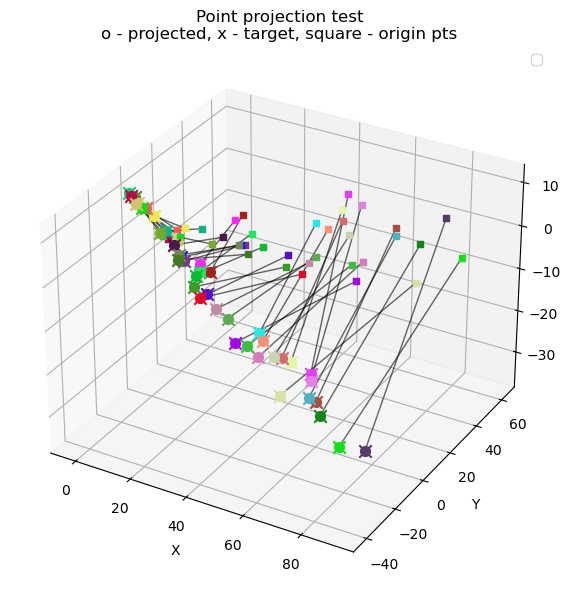

Projecction error:
- mean: 5.508521676958607e-06
- std: 3.4763068796347963e-06
pts 0 - error: 9.669578155275166e-06
pts 1 - error: 2.525732522595844e-06
pts 2 - error: 1.1323684840842572e-05
pts 3 - error: 4.278756705200624e-06
pts 4 - error: 4.945743407539991e-07
pts 5 - error: 8.035791307319161e-06
pts 6 - error: 3.6134872500817115e-06
pts 7 - error: 5.955281411466537e-06
pts 8 - error: 7.78999375679516e-06
pts 9 - error: 8.847232588995385e-06
pts 10 - error: 2.178524138191792e-06
pts 11 - error: 7.287243290179289e-06
pts 12 - error: 5.491888424177078e-06
pts 13 - error: 1.2531929590757981e-06
pts 14 - error: 6.223851257232968e-06
pts 15 - error: 6.586775079033646e-06
pts 16 - error: 3.508400123542261e-06
pts 17 - error: 1.9568532409783955e-06
pts 18 - error: 8.858642986195216e-06
pts 19 - error: 1.1645216548703251e-05
pts 20 - error: 5.467195043379244e-06
pts 21 - error: 2.4308842494805093e-06
pts 22 - error: 1.4014175156688465e-05
pts 23 - error: 1.607160625374885e-06
pts 24 - erro

In [83]:
error = visu(projected_pts, gt_pts, origin_pts)


print(f'Projecction error:\n- mean: {np.mean(error)}\n- std: {np.std(error)}')
for i in range(len(error)):
    print(f'pts {i} - error: {error[i]}')



# Test 2 - movement approximation, constant speed model

In [18]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'
train_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/training.yaml'

with open(model_config_pth, "r") as f:
    model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
    sonar_config = Box(yaml.safe_load(f))

with open(train_config_pth, "r") as f:
    train_config = Box(yaml.safe_load(f))


PatchGraph_i = Graph_interference(model_config, sonar_config)
PatchGraph_t = Graph_train(model_config, sonar_config, train_config)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
# test data 

data_pth_sim = f'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/fls/352.png'

# read frame 
frame_sim = cv2.imread(data_pth_sim, 0)

frame_sim = frame_sim.astype(np.uint8)
frame_sim = torch.from_numpy(frame_sim) # convert to torch tensor
frame_sim = frame_sim.float().unsqueeze(0).unsqueeze(0).unsqueeze(0)


frames_inm_series = 5
batch_size = 2
t_0 = 1.0
dt = 0.5

frame_sim_b = torch.cat([frame_sim for _ in range(frames_inm_series)], axis = 1)
frame_sim_b = torch.cat([frame_sim_b for _ in range(batch_size)], axis = 0)


time_tensor = torch.tensor([t_0 + i*dt for i in range(frames_inm_series)], device = device, dtype = torch.float)
time_tensor = time_tensor.unsqueeze(0)
time_tensor = torch.cat([time_tensor for _ in range(batch_size)], dim = 0)


print('-'*80)
print(f'Input data format:')
print(f'simulated tensor shape: {frame_sim.shape}, data type: {frame_sim.dtype}')
print(f'simulated tensors batch shape: {frame_sim_b.shape}, data type: {frame_sim_b.dtype}')
print(f'time tensor: {time_tensor.shape}')
print('-'*80)

--------------------------------------------------------------------------------
Input data format:
simulated tensor shape: torch.Size([1, 1, 1, 800, 768]), data type: torch.float32
simulated tensors batch shape: torch.Size([2, 5, 1, 800, 768]), data type: torch.float32
time tensor: torch.Size([2, 5])
--------------------------------------------------------------------------------


In [20]:
def plot_test_case(title, p_prev, p_last, p_pred, p_expected=None):
    def to_np(x):
        if x is None: return None
        # Jeśli to już numpy, zwróć. Jeśli tensor, skonwertuj.
        if torch.is_tensor(x): return x.detach().cpu().numpy()
        return x

    # Konwersja wszystkich wejść
    p_prev_np = to_np(p_prev)
    p_last_np = to_np(p_last)
    p_pred_np = to_np(p_pred)
    p_expected_np = to_np(p_expected)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    def draw_frame_full(pose_np, label, length=0.2, is_pred=False):
        pos = pose_np[:3]
        quat = pose_np[3:]
        
        # Rysujemy główny punkt
        size = 150 if is_pred else 100
        ax.scatter(pos[0], pos[1], pos[2], label=label, s=size, edgecolors='k')

        # Obliczamy rotację
        norm = np.linalg.norm(quat)
        if norm > 1e-6:
            r = R.from_quat(quat / norm)
            rot_mat = r.as_matrix()
            
            # Osie: X=czerwony, Y=zielony, Z=niebieski
            colors = ['r', 'g', 'b']
            for i in range(3):
                ax.quiver(pos[0], pos[1], pos[2], 
                          rot_mat[0, i], rot_mat[1, i], rot_mat[2, i], 
                          color=colors[i], length=length, normalize=True, alpha=0.8)
        else:
            print(f"Warning: Zero norm quat for {label}")

    # Rysowanie klatek
    draw_frame_full(p_prev_np, 't_(k-2)')
    draw_frame_full(p_last_np, 't_(k-1)')
    draw_frame_full(p_pred_np, 't_k prediction', length=0.4, is_pred=True)
    
    # Rysowanie punktu oczekiwanego (jeśli podano)
    if p_expected_np is not None:
        pos_ex = p_expected_np[:3]
        ax.scatter(pos_ex[0], pos_ex[1], pos_ex[2], 
                   c='black', marker='x', s=200, label='t_k expected', linewidths=3)
        # Opcjonalnie: dorysowanie osi dla oczekiwanego (półprzezroczyste)
        draw_frame_full(p_expected_np, 'expected', length=0.2)

    # Linia trajektorii
    path = np.array([p_prev_np[:3], p_last_np[:3], p_pred_np[:3]])
    ax.plot(path[:,0], path[:,1], path[:,2], 'k--', alpha=0.4)

    ax.set_title(title)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend()
    
    # Automatyczne skalowanie z lekkim marginesem
    all_coords = np.vstack([p_prev_np[:3], p_last_np[:3], p_pred_np[:3]])
    if p_expected_np is not None:
        all_coords = np.vstack([all_coords, p_expected_np[:3]])
        
    mins = all_coords.min(axis=0)
    maxs = all_coords.max(axis=0)
    center = (mins + maxs) / 2
    dist = max(maxs - mins) / 2 + 0.2 # margines
    
    ax.set_xlim(center[0] - dist, center[0] + dist)
    ax.set_ylim(center[1] - dist, center[1] + dist)
    ax.set_zlim(center[2] - dist, center[2] + dist)
    
    plt.show()

In [21]:
# Test data:

# rotation
t_k_2 = 0.5
t_k_1 = 1.0
t_k_0 = 1.5

rot_1_deg = random.randint(0, 90)
rot_2_deg = 2 * rot_1_deg
rot_3_deg = (t_k_0 - t_k_1) / (t_k_1 - t_k_2) * rot_1_deg  + rot_2_deg

# shift 
shift = np.array([random.random(), random.random(), random.random()])

# combine movements
# q_0deg = R.from_euler('z', 0 , degrees=True).as_quat() # init rotation - 0 deg 
q_1 = R.from_euler('z', rot_1_deg , degrees=True).as_quat() # rotation 1 - quaterions
q_2 = R.from_euler('z', rot_2_deg, degrees=True).as_quat() # rotation 2 - 2 * rotation 1 - quaterions
q_3 = R.from_euler('z', rot_3_deg, degrees=True).as_quat() # rotation 3 - 4 * rotation 1 - quaterions

p_t2 = torch.tensor(np.concatenate([[0,0,0], q_1]))  # for time t_k-2
p_t1 = torch.tensor(np.concatenate([shift, q_2]))  # for time t_k-1

# Expected point for time t_k
p_t0  = torch.tensor(np.concatenate([2*shift, q_3]), dtype=torch.float32)

print('-'*50)
print(f'Movement:')
print(f'    shift:\n    x:{shift[0]}\n    y:{shift[1]}\n    z:{shift[2]}')
print(f'    rotation:\n    x: 0\n    y: 0\n    z: {rot_1_deg}')

n = 4



--------------------------------------------------
Movement:
    shift:
    x:0.0852438806935496
    y:0.3267692857633099
    z:0.06226899689057264
    rotation:
    x: 0
    y: 0
    z: 82


Motion model: linear
act n: 4
predicted pose for time t_k-2: tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6561, 0.7547],
       dtype=torch.float64)
predicted pose for time t_k-1: tensor([0.0852, 0.3268, 0.0623, 0.0000, 0.0000, 0.9903, 0.1392],
       dtype=torch.float64)
predicted pose for time t_k: tensor([ 0.1705,  0.6535,  0.1245,  0.0000,  0.0000,  0.8387, -0.5446])


C:\Users\janis\AppData\Local\Temp\ipykernel_18616\4049833290.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  PatchGraph_i.poses[n-2, :] = torch.tensor(p_t2)
C:\Users\janis\AppData\Local\Temp\ipykernel_18616\4049833290.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  PatchGraph_i.poses[n-1, :] = torch.tensor(p_t1)


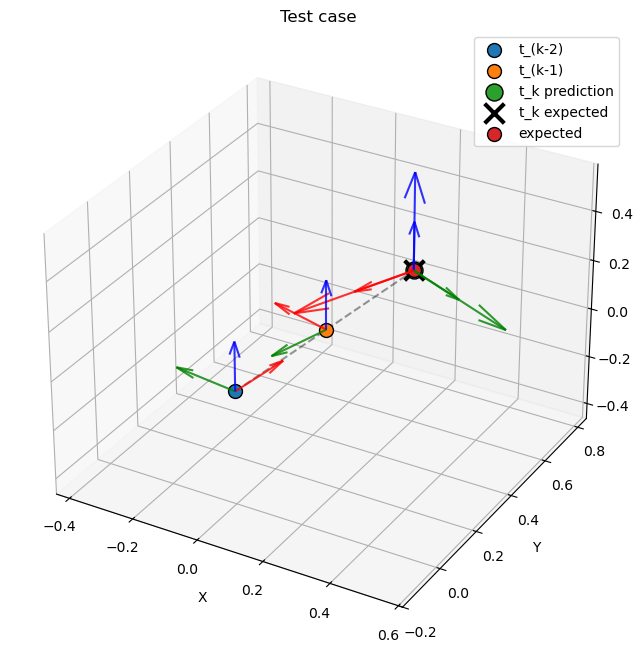

>    Result: PASSED


In [22]:
# =============================================
# Interference graph 
# =============================================


PatchGraph_i.frame_n = n

PatchGraph_i.poses[n-2, :] = torch.tensor(p_t2)
PatchGraph_i.poses[n-1, :] = torch.tensor(p_t1)

PatchGraph_i.time[n-2] = 0.5 #torch.tensor(0.5)
PatchGraph_i.time[n-1] = 1.0 #torch.tensor(1.0)
PatchGraph_i.time[n] = 1.5 #torch.tensor(1.5)

print(f'Motion model: {PatchGraph_i.motion_model}')

PatchGraph_i.approx_movement(device)

p_pred = PatchGraph_i.poses[n, :]

print(f'predicted pose for time t_k-2: {p_t2}')
print(f'predicted pose for time t_k-1: {p_t1}')
print(f'predicted pose for time t_k: {p_pred}')
plot_test_case('Test case', p_t2, p_t1, p_pred, p_expected=p_t0)

if all(list(p_pred.detach().cpu())) == all(list(p_t0.detach().cpu())):
    print('>    Result: PASSED')
else:
    print('>    Result: FAILED')